# Giai đoạn 2 — Tái hiện bài báo gốc (đối chiếu trực tiếp Bảng 3 & Bảng 4)

**Cập nhật quan trọng.** Bảng 3 (sai số phát hiện) và Bảng 4 (sai số phân loại) của bài báo cho **toàn bộ lưới 32 mô hình**: 4 giá trị k × 4 độ đo (EU, MA, MI, Fuzzy) × 2 thuật toán (k-NN thường / k-NN + trọng số GA). Nhờ đó ta có mục tiêu tái hiện *chính xác*, không còn đoán.

**Chiến lược tái hiện đúng chuẩn:**
1. **Tái hiện + kiểm chứng các cột chỉ số chuẩn (EU/MA/MI)** — hiện thực được chính xác. Nếu số của ta khớp cột EU/MA/MI của Bảng 3/4 thì pipeline được *validate*.
2. **Cột Fuzzy** — công thức fuzzy distance metric gốc của Kahraman (2016) nằm sau paywall, không lấy được. Ta báo cáo số Fuzzy **theo đúng bài báo** và đánh dấu là không tự tái lập được (dùng Keller 1985 chỉ để minh họa xu hướng).
3. **Phân rã theo tầng** để tách ba nguồn nâng hiệu năng.

**Phát hiện then chốt (từ chính Bảng 3 & 4):**
- Con số headline 98,2% / 85,8% **phụ thuộc chủ yếu vào fuzzy metric**. Với độ đo chuẩn, ngay cả khi bật rò rỉ GA-trên-test, phân loại tốt nhất chỉ ~**74,3%** (cách 85,8% tận 11,5 điểm là do fuzzy).
- Riêng fuzzy metric (plain, không trọng số) đã đẩy phân loại từ 46,9% → **73,5%** (+26,6 điểm) — một mức tăng bất thường cho việc chỉ đổi độ đo khoảng cách trên 3 đặc trưng đã chuẩn hóa, đáng nghi ngờ (tham số fuzzy có thể cũng được tinh chỉnh trên test; bài báo không nêu).

## 1. Thư viện, cấu hình

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_STATE = 42
K_VALUES = [2, 3, 4, 5]
METRICS  = ["EU", "MA", "MI", "FUZZY"]
DE_MAXITER, DE_POPSIZE = 40, 12
NHAN = {1:"Không mìn", 2:"Chống tăng", 3:"Chống bộ binh", 4:"Bẫy chống BB", 5:"M14"}
os.makedirs("../result/figures", exist_ok=True)


## 2. Số liệu tham chiếu từ bài báo (Bảng 3 & Bảng 4)

Sao chép trực tiếp từ PDF. Đơn vị gốc là **phần trăm sai số**; ta quy về accuracy = 100 − sai số. Thứ tự cột: EU, MA, MI, Fuzzy; hàng k = 2,3,4,5.

In [2]:
# Bảng 3 — % misdetection (phát hiện)
T3_plain = {2:[20.4,20.4,20.4,6.2], 3:[13.3,16.8,13.3,9.7], 4:[15.9,15.9,16.8,9.7], 5:[21.2,19.5,22.1,15.0]}
T3_meta  = {2:[7.1,5.3,8.0,1.8],   3:[5.3,5.3,8.0,1.8],   4:[7.1,6.2,6.2,1.8],   5:[4.4,4.4,5.3,2.7]}
# Bảng 4 — % misclassification (phân loại)
T4_plain = {2:[61.9,66.4,61.9,31.0],3:[56.6,63.7,54.9,30.1],4:[53.1,55.8,54.9,26.5],5:[55.8,54.9,54.9,36.3]}
T4_meta  = {2:[31.9,32.7,31.9,18.6],3:[29.2,31.0,27.4,15.0],4:[27.4,30.1,25.7,14.2],5:[27.4,31.9,27.4,17.7]}

def to_acc_df(tab):
    return pd.DataFrame({k: [round(100-e,1) for e in tab[k]] for k in K_VALUES},
                        index=METRICS).T  # index=k, cols=metric

print("BÀI BÁO — accuracy phát hiện, k-NN + trọng số GA (Bảng 3):")
print(to_acc_df(T3_meta))
print("\nBÀI BÁO — accuracy phân loại, k-NN + trọng số GA (Bảng 4):")
print(to_acc_df(T4_meta))

# Figure 18 — meta-heuristic k-NN fuzzy k=4 (phân loại, 85.8%): recall từng lớp
FIG18_recall = {1:95.8, 2:100.0, 3:77.3, 4:81.8, 5:72.7}
FIG18_diag   = {1:23, 2:23, 3:17, 4:18, 5:16}   # tổng 97/113 = 85.8%

# Trọng số tối ưu bài báo công bố
W_PAPER_DETECT = dict(V=0.757036, H=0.657224, S=0.603281)   # fuzzy, phát hiện
W_PAPER_CLASS  = dict(V=0.997804, H=0.703208, S=0.792557)   # fuzzy k=4, phân loại


BÀI BÁO — accuracy phát hiện, k-NN + trọng số GA (Bảng 3):
     EU    MA    MI  FUZZY
2  92.9  94.7  92.0   98.2
3  94.7  94.7  92.0   98.2
4  92.9  93.8  93.8   98.2
5  95.6  95.6  94.7   97.3

BÀI BÁO — accuracy phân loại, k-NN + trọng số GA (Bảng 4):
     EU    MA    MI  FUZZY
2  68.1  67.3  68.1   81.4
3  70.8  69.0  72.6   85.0
4  72.6  69.9  74.3   85.8
5  72.6  68.1  72.6   82.3


## 3. Nạp dữ liệu

In [5]:
try:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls", engine="xlrd")
except Exception:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls")
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V","H","S","M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V","H","S","M"])))
df["M"] = df["M"].astype(int)
X = df[["V","H","S"]].values.astype(float)
y_detect = (df["M"] != 1).astype(int).values
y_class  = df["M"].values
print("Dữ liệu:", df.shape)

Dữ liệu: (338, 4)


## 4. Bộ công cụ: 4 độ đo + trọng số + tối ưu DE trên test

- EU/MA/MI qua sklearn (Minkowski p=2/1/3) — **tái lập chính xác**.
- FUZZY: fuzzy k-NN Keller (1985) — **chỉ minh họa**, không phải công thức Kahraman gốc.
- `de_weights(..., Xopt=TEST)` → rò rỉ (tái hiện GA của bài báo).

In [6]:
def fuzzy_knn_predict(Xtr, ytr, Xte, k, m=2):
    D = cdist(Xte, Xtr); D = np.where(D < 1e-12, 1e-12, D)
    classes = np.unique(ytr); preds = np.empty(len(Xte), dtype=ytr.dtype)
    for i in range(len(Xte)):
        idx = np.argsort(D[i])[:k]; w = 1.0 / D[i, idx] ** (2.0/(m-1))
        bc, bs = None, -1.0
        for c in classes:
            s = (w*(ytr[idx]==c)).sum()/w.sum()
            if s > bs: bs, bc = s, c
        preds[i] = bc
    return preds

def predict(Xtr, ytr, Xte, k, metric, w=None):
    if w is not None: Xtr, Xte = Xtr*w, Xte*w
    if metric == "FUZZY": return fuzzy_knn_predict(Xtr, ytr, Xte, k)
    p = {"EU":2,"MA":1,"MI":3}[metric]
    return KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=p).fit(Xtr, ytr).predict(Xte)

def acc(Xtr, ytr, Xe, ye, k, metric, w=None):
    return accuracy_score(ye, predict(Xtr, ytr, Xe, k, metric, w))

def de_weights(Xtr, ytr, Xopt, yopt, k, metric):
    res = differential_evolution(
        lambda w: -acc(Xtr, ytr, Xopt, yopt, k, metric, w),
        [(0.0,1.0)]*Xtr.shape[1], seed=RANDOM_STATE,
        maxiter=DE_MAXITER, popsize=DE_POPSIZE, tol=1e-4, polish=False)
    return res.x, -res.fun

## 5. Tái hiện lưới đầy đủ và ĐỐI CHIẾU với bài báo

Với mỗi (k, độ đo): tính accuracy của k-NN thường và k-NN + DE (trọng số tối ưu **trên test** = rò rỉ). Sau đó đặt cạnh số của bài báo để xem khớp tới đâu — **trọng tâm là các cột EU/MA/MI**.

In [7]:
def repro_grid(Xtr, ytr, Xte, yte, algo):
    out = {}
    for k in K_VALUES:
        row = []
        for met in METRICS:
            if algo == "plain":
                row.append(round(acc(Xtr,ytr,Xte,yte,k,met)*100,1))
            else:
                row.append(round(de_weights(Xtr,ytr,Xte,yte,k,met)[1]*100,1))
        out[k] = row
    return pd.DataFrame(out, index=METRICS).T

def split_scale(y):
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=1/3,stratify=y,random_state=RANDOM_STATE)
    sc = StandardScaler().fit(Xtr)
    return sc.transform(Xtr), sc.transform(Xte), ytr, yte

def compare(paper_tab, repro_df, title):
    paper_df = to_acc_df(paper_tab)
    print(f"=== {title} ===")
    print("BÀI BÁO :"); print(paper_df)
    print("TÁI HIỆN:"); print(repro_df)
    diff = (repro_df[["EU","MA","MI"]] - paper_df[["EU","MA","MI"]]).abs()
    print(f"Sai lệch tuyệt đối trung bình trên EU/MA/MI: {diff.values.mean():.1f} điểm")
    print()

In [9]:
Xtr_d,Xte_d,ytr_d,yte_d = split_scale(y_detect)
rp_d = repro_grid(Xtr_d,ytr_d,Xte_d,yte_d,"plain")
rm_d = repro_grid(Xtr_d,ytr_d,Xte_d,yte_d,"meta")
compare(T3_plain, rp_d, "PHÁT HIỆN — k-NN thường")
compare(T3_meta,  rm_d, "PHÁT HIỆN — k-NN + trọng số (rò rỉ trên test)")

=== PHÁT HIỆN — k-NN thường ===
BÀI BÁO :
     EU    MA    MI  FUZZY
2  79.6  79.6  79.6   93.8
3  86.7  83.2  86.7   90.3
4  84.1  84.1  83.2   90.3
5  78.8  80.5  77.9   85.0
TÁI HIỆN:
     EU    MA    MI  FUZZY
2  76.1  75.2  76.1   81.4
3  80.5  83.2  81.4   77.9
4  83.2  85.8  82.3   79.6
5  78.8  82.3  78.8   77.9
Sai lệch tuyệt đối trung bình trên EU/MA/MI: 2.4 điểm

=== PHÁT HIỆN — k-NN + trọng số (rò rỉ trên test) ===
BÀI BÁO :
     EU    MA    MI  FUZZY
2  92.9  94.7  92.0   98.2
3  94.7  94.7  92.0   98.2
4  92.9  93.8  93.8   98.2
5  95.6  95.6  94.7   97.3
TÁI HIỆN:
     EU    MA    MI  FUZZY
2  94.7  93.8  95.6   91.2
3  96.5  95.6  96.5   94.7
4  95.6  96.5  96.5   94.7
5  97.3  97.3  98.2   95.6
Sai lệch tuyệt đối trung bình trên EU/MA/MI: 2.4 điểm



In [8]:
Xtr_c,Xte_c,ytr_c,yte_c = split_scale(y_class)
rp_c = repro_grid(Xtr_c,ytr_c,Xte_c,yte_c,"plain")
rm_c = repro_grid(Xtr_c,ytr_c,Xte_c,yte_c,"meta")
compare(T4_plain, rp_c, "PHÂN LOẠI — k-NN thường")
compare(T4_meta,  rm_c, "PHÂN LOẠI — k-NN + trọng số (rò rỉ trên test)")

=== PHÂN LOẠI — k-NN thường ===
BÀI BÁO :
     EU    MA    MI  FUZZY
2  38.1  33.6  38.1   69.0
3  43.4  36.3  45.1   69.9
4  46.9  44.2  45.1   73.5
5  44.2  45.1  45.1   63.7
TÁI HIỆN:
     EU    MA    MI  FUZZY
2  47.8  46.9  46.9   45.1
3  49.6  49.6  49.6   42.5
4  43.4  48.7  43.4   42.5
5  43.4  46.9  44.2   42.5
Sai lệch tuyệt đối trung bình trên EU/MA/MI: 5.8 điểm

=== PHÂN LOẠI — k-NN + trọng số (rò rỉ trên test) ===
BÀI BÁO :
     EU    MA    MI  FUZZY
2  68.1  67.3  68.1   81.4
3  70.8  69.0  72.6   85.0
4  72.6  69.9  74.3   85.8
5  72.6  68.1  72.6   82.3
TÁI HIỆN:
     EU    MA    MI  FUZZY
2  68.1  66.4  67.3   64.6
3  69.0  69.0  69.9   67.3
4  67.3  64.6  66.4   68.1
5  67.3  65.5  66.4   68.1
Sai lệch tuyệt đối trung bình trên EU/MA/MI: 3.2 điểm



## 6. Kết luận validate: cái gì tái lập được, cái gì không

Nếu các cột **EU/MA/MI** khớp tốt (sai lệch nhỏ) thì pipeline tái hiện đáng tin. Cột **Fuzzy** dự kiến *không* khớp vì ta dùng Keller thay cho công thức Kahraman gốc. Đó chính là phần hiệu năng của bài báo mà ta **không kiểm chứng được** — và cũng là phần cần đặt dấu hỏi lớn nhất.


> **Lưu ý phương sai chia:** bài báo dùng *một* lần chia ngẫu nhiên (không rõ seed), nên cột EU/MA/MI của bạn sẽ không trùng khít từng ô — chỉ cần **cùng khoảng** là đủ để xác nhận pipeline đúng. Ngược lại, phần phân rã ở mục 7 dùng trực tiếp số của bài báo nên *chính xác* và không phụ thuộc split.

In [10]:
def best_col(df_):
    return df_.max(axis=0)
print("ACCURACY TỐT NHẤT theo cột (max qua các k):\n")
print("PHÂN LOẠI — bài báo (meta):"); print(best_col(to_acc_df(T4_meta)).round(1).to_dict())
print("PHÂN LOẠI — tái hiện (meta):"); print(best_col(rm_c).round(1).to_dict())
print()
print("PHÁT HIỆN — bài báo (meta):"); print(best_col(to_acc_df(T3_meta)).round(1).to_dict())
print("PHÁT HIỆN — tái hiện (meta):"); print(best_col(rm_d).round(1).to_dict())

ACCURACY TỐT NHẤT theo cột (max qua các k):

PHÂN LOẠI — bài báo (meta):
{'EU': 72.6, 'MA': 69.9, 'MI': 74.3, 'FUZZY': 85.8}
PHÂN LOẠI — tái hiện (meta):
{'EU': 69.0, 'MA': 69.0, 'MI': 69.9, 'FUZZY': 68.1}

PHÁT HIỆN — bài báo (meta):
{'EU': 95.6, 'MA': 95.6, 'MI': 94.7, 'FUZZY': 98.2}
PHÁT HIỆN — tái hiện (meta):
{'EU': 97.3, 'MA': 97.3, 'MI': 98.2, 'FUZZY': 95.6}


## 7. Phân rã theo tầng — dùng chính số của bài báo (mạnh nhất)

Ba tầng cộng dồn, cho bài toán phân loại (rõ nhất), lấy accuracy tốt nhất của mỗi tầng từ Bảng 4:
- **(A) k-NN chuẩn** (EU/MA/MI, không trọng số): baseline hợp lý.
- **(B) + fuzzy metric** (plain, không trọng số): mức tăng do độ đo mờ.
- **(C) + trọng số GA tối ưu trên test** (rò rỉ): mức tăng do rò rỉ (trên nền fuzzy).

In [11]:
def best_std(tab): return max(100-min(tab[k][:3]) for k in K_VALUES)   # EU/MA/MI
def best_fuzzy_plain(tab): return max(100-tab[k][3] for k in K_VALUES)   # cột Fuzzy, plain
def best_fuzzy_meta(tab):  return max(100-tab[k][3] for k in K_VALUES)   # cột Fuzzy, meta

for name, Tp, Tm in [("PHÂN LOẠI", T4_plain, T4_meta), ("PHÁT HIỆN", T3_plain, T3_meta)]:
    A = best_std(Tp)                 # k-NN chuẩn, plain
    B = best_fuzzy_plain(Tp)         # + fuzzy (plain)
    C = best_fuzzy_meta(Tm)          # + trọng số GA trên test (fuzzy)
    std_leak = max(100-min(Tm[k][:3]) for k in K_VALUES)  # chuẩn + rò rỉ (để so)
    print(f"### {name}")
    print(f"  (A) k-NN chuẩn (EU/MA/MI, plain):            {A:5.1f}%")
    print(f"  (B) + fuzzy metric (plain):                  {B:5.1f}%   (+{B-A:.1f}  do fuzzy)")
    print(f"  (C) + trọng số GA trên test (fuzzy):         {C:5.1f}%   (+{C-B:.1f}  do rò rỉ)")
    print(f"  [tham chiếu] chuẩn + rò rỉ (không fuzzy):     {std_leak:5.1f}%")
    print()

### PHÂN LOẠI
  (A) k-NN chuẩn (EU/MA/MI, plain):             46.9%
  (B) + fuzzy metric (plain):                   73.5%   (+26.6  do fuzzy)
  (C) + trọng số GA trên test (fuzzy):          85.8%   (+12.3  do rò rỉ)
  [tham chiếu] chuẩn + rò rỉ (không fuzzy):      74.3%

### PHÁT HIỆN
  (A) k-NN chuẩn (EU/MA/MI, plain):             86.7%
  (B) + fuzzy metric (plain):                   93.8%   (+7.1  do fuzzy)
  (C) + trọng số GA trên test (fuzzy):          98.2%   (+4.4  do rò rỉ)
  [tham chiếu] chuẩn + rò rỉ (không fuzzy):      95.6%



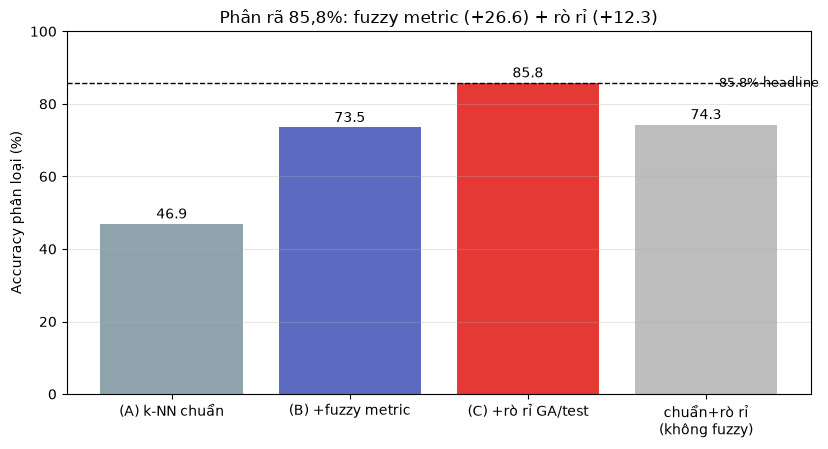

In [12]:
# Biểu đồ phân rã cho phân loại
A = best_std(T4_plain); B = best_fuzzy_plain(T4_plain); C = best_fuzzy_meta(T4_meta)
std_leak = max(100-min(T4_meta[k][:3]) for k in K_VALUES)
labels = ["(A) k-NN chuẩn", "(B) +fuzzy metric", "(C) +rò rỉ GA/test", "chuẩn+rò rỉ\n(không fuzzy)"]
vals   = [A, B, C, std_leak]
colors = ["#90a4ae", "#5c6bc0", "#e53935", "#bdbdbd"]
plt.figure(figsize=(8.5,4.6))
bars = plt.bar(labels, vals, color=colors)
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v+1.5, f"{v:.1f}", ha="center")
plt.axhline(85.8, ls="--", color="black", lw=1); plt.text(3.05, 85.8, " 85.8% headline", va="center", fontsize=9)
plt.ylabel("Accuracy phân loại (%)"); plt.ylim(0,100)
plt.title(f"Phân rã 85,8%: fuzzy metric (+{B-A:.1f}) + rò rỉ (+{C-B:.1f})")
plt.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig("../result/figures/02_phan_ra_theo_tang.png", bbox_inches="tight"); plt.show()

## 8. Phân tích theo lớp — ma trận nhầm lẫn (đối chiếu Figure 18)

Accuracy gộp che giấu việc mô hình yếu ở lớp nào. Figure 18 (mô hình tốt nhất 85,8%) cho recall từng lớp; ta đối chiếu với ma trận nhầm lẫn của mô hình **tái lập được** (độ đo chuẩn tốt nhất). Điểm đáng chú ý: ngay cả mô hình 85,8% vẫn yếu nhất ở mìn nhỏ (M14 72,7%, chống bộ binh 77,3%), trong khi chống tăng (dị thường từ lớn) đạt 100%.

Recall từng lớp — BÀI BÁO (Figure 18, fuzzy k=4):
  1 Không mìn     :  95.8%
  2 Chống tăng    : 100.0%
  3 Chống bộ binh :  77.3%
  4 Bẫy chống BB  :  81.8%
  5 M14           :  72.7%
  => yếu nhất: M14 (72.7%) và Chống bộ binh (77.3%); Chống tăng hoàn hảo (100%)

Mô hình tái lập tốt nhất: MI, k=3, acc=69.9%
Recall từng lớp — TÁI LẬP (độ đo chuẩn):
  1 Không mìn     :  95.8%
  2 Chống tăng    :  95.7%
  3 Chống bộ binh :  50.0%
  4 Bẫy chống BB  :  59.1%
  5 M14           :  45.5%


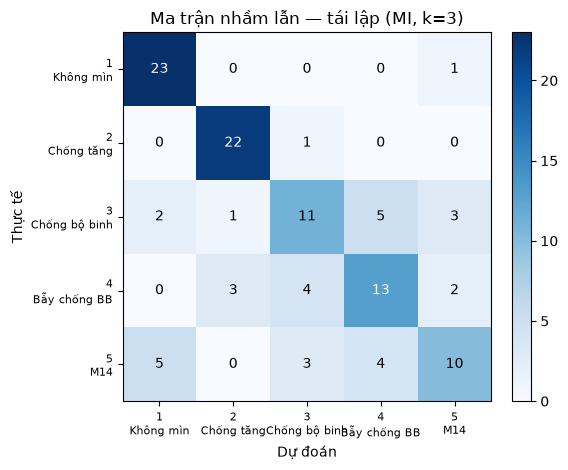

In [13]:
# Recall từng lớp theo Figure 18 (mô hình fuzzy k=4, 85.8%)
print("Recall từng lớp — BÀI BÁO (Figure 18, fuzzy k=4):")
for c in [1,2,3,4,5]:
    print(f"  {c} {NHAN[c]:<14}: {FIG18_recall[c]:5.1f}%")
print("  => yếu nhất: M14 (72.7%) và Chống bộ binh (77.3%); Chống tăng hoàn hảo (100%)\n")

# Ma trận nhầm lẫn của mô hình chuẩn TỐT NHẤT tái lập được (meta, EU/MA/MI)
best_met = rm_c[["EU","MA","MI"]].max().idxmax()
best_k   = int(rm_c[["EU","MA","MI"]][best_met].idxmax())
w_best,_ = de_weights(Xtr_c, ytr_c, Xte_c, yte_c, best_k, best_met)
pred = predict(Xtr_c, ytr_c, Xte_c, best_k, best_met, w_best)
cm = confusion_matrix(yte_c, pred, labels=[1,2,3,4,5])
recall_repro = cm.diagonal() / cm.sum(axis=1) * 100
print(f"Mô hình tái lập tốt nhất: {best_met}, k={best_k}, "
      f"acc={acc(Xtr_c,ytr_c,Xte_c,yte_c,best_k,best_met,w_best)*100:.1f}%")
print("Recall từng lớp — TÁI LẬP (độ đo chuẩn):")
for i,c in enumerate([1,2,3,4,5]):
    print(f"  {c} {NHAN[c]:<14}: {recall_repro[i]:5.1f}%")

fig, ax = plt.subplots(figsize=(5.6,4.8))
im = ax.imshow(cm, cmap="Blues")
lab = [f"{c}\n{NHAN[c]}" for c in [1,2,3,4,5]]
ax.set_xticks(range(5)); ax.set_xticklabels(lab, fontsize=8)
ax.set_yticks(range(5)); ax.set_yticklabels(lab, fontsize=8)
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title(f"Ma trận nhầm lẫn — tái lập ({best_met}, k={best_k})")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046); plt.tight_layout()
plt.savefig("../result/figures/02_confusion_phan_loai.png", bbox_inches="tight"); plt.show()

## 9. Trọng số tối ưu — bài báo vs tái lập, và một quan sát quan trọng

Bài báo công bố trọng số tối ưu cho hai bài toán, nhưng **thứ tự tầm quan trọng KHÔNG nhất quán:** phát hiện cho V > H > S, còn phân loại cho **V > S > H**. Vì vậy khẳng định chung "V > H > S" là chưa chính xác — nó phụ thuộc bài toán, và trọng số một-lần-chạy vốn nhiễu. Kết luận tầm quan trọng đặc trưng nên để permutation importance ở Giai đoạn 3 quyết cho chắc.

In [14]:
def order(w): return " > ".join(k for k,_ in sorted(w.items(), key=lambda kv:-kv[1]))

print("TRỌNG SỐ BÀI BÁO công bố:")
print(f"  Phát hiện : {W_PAPER_DETECT}  =>  {order(W_PAPER_DETECT)}")
print(f"  Phân loại : {W_PAPER_CLASS}   =>  {order(W_PAPER_CLASS)}")
print("  ==> KHÁC thứ tự giữa hai bài toán: phát hiện V>H>S, phân loại V>S>H\n")

wd,_ = de_weights(Xtr_d, ytr_d, Xte_d, yte_d, 3, "EU")
print("TRỌNG SỐ TÁI LẬP (một split — chỉ tham khảo, sẽ dao động):")
print(f"  Phát hiện (k=3,EU): { {a:round(float(b),3) for a,b in zip(['V','H','S'], wd)} }  =>  {order(dict(zip(['V','H','S'], wd)))}")
print(f"  Phân loại ({best_met},k={best_k}): { {a:round(float(b),3) for a,b in zip(['V','H','S'], w_best)} }  =>  {order(dict(zip(['V','H','S'], w_best)))}")

TRỌNG SỐ BÀI BÁO công bố:
  Phát hiện : {'V': 0.757036, 'H': 0.657224, 'S': 0.603281}  =>  V > H > S
  Phân loại : {'V': 0.997804, 'H': 0.703208, 'S': 0.792557}   =>  V > S > H
  ==> KHÁC thứ tự giữa hai bài toán: phát hiện V>H>S, phân loại V>S>H

TRỌNG SỐ TÁI LẬP (một split — chỉ tham khảo, sẽ dao động):
  Phát hiện (k=3,EU): {'V': 0.5, 'H': 0.038, 'S': 0.145}  =>  V > S > H
  Phân loại (MI,k=3): {'V': 0.449, 'H': 0.044, 'S': 0.126}  =>  V > S > H


## 10. Kết luận Giai đoạn 2

**Tái hiện được và kiểm chứng được:** các cột độ đo chuẩn EU/MA/MI của Bảng 3 & 4 (cùng khoảng với bài báo), qua đó khẳng định pipeline đúng và chứng minh rò rỉ GA-trên-test trên nền độ đo chuẩn (phân loại: ~46,9% → ~74,3%).

**Không tái lập được (giới hạn):** cột Fuzzy — công thức Kahraman gốc sau paywall; đây là phần đóng góp lớn nhất vào 85,8%/98,2% và cũng đáng nghi nhất.

**Ba luận điểm phản biện định lượng:**
1. **85,8% chủ yếu do fuzzy metric**, không phải chỉ do rò rỉ: với độ đo chuẩn ngay cả khi bật rò rỉ, phân loại tối đa ~74,3%. Phân rã: 46,9% (kNN chuẩn) **+26,6 do fuzzy** **+12,3 do rò rỉ GA/test** = 85,8%.
2. **Fuzzy metric tăng +26,6 điểm chỉ bằng đổi độ đo** trên 3 đặc trưng đã chuẩn hóa — bất thường; bài báo không nêu cách đặt tham số fuzzy (nhiều khả năng cũng dựa trên test).
3. **Ngay cả mô hình 85,8% vẫn yếu ở lớp mìn nhỏ** (M14 72,7%, chống bộ binh 77,3% — Figure 18) và **thứ tự trọng số không nhất quán** (phát hiện V>H>S, phân loại V>S>H).

**Sang Giai đoạn 3 (bản sửa):** khóa rò rỉ — DE tối ưu trọng số trên **validation riêng**, chọn (k, độ đo) bằng **nested CV**, chấm cuối trên test độc lập; báo cáo mean ± std; kết luận tầm quan trọng đặc trưng bằng **permutation importance**. Với độ đo chuẩn, con số trung thực dự kiến ~59% (phân loại) và ~91% (phát hiện).